In [4]:
import copy
from   random import choice
import math 

import numpy as np
from   sklearn.cluster import HDBSCAN, DBSCAN
import hdbscan

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import NaiveDE
import SpatialDE
import pandas as pd

import networkx as nx

from plot import *
from data import *
from filt import *
from filt import ITNI, ITSNI, VNI

from scipy.optimize import minimize
from scipy.stats import nbinom


from matplotlib.patches import Circle
from matplotlib.lines import Line2D

import scanpy
from sklearn.neighbors import NearestNeighbors

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from collections import deque
from collections import defaultdict


In [5]:
#Definzione colori + grafica

W  = '#efefd0'
B  = '#004e89'
Or = "#ff6b35"
mpl.rcParams['text.color']       = B
mpl.rcParams['axes.labelcolor']  = B
mpl.rcParams['axes.edgecolor']   = B
mpl.rcParams['axes.facecolor']   = W
mpl.rcParams['figure.facecolor'] = W
mpl.rcParams['xtick.color']      = B
mpl.rcParams['ytick.color']      = B
mpl.rcParams['font.family']      = "monospace"

c1 = "#35cde2"
c2 = "#ab2b2b"
c3 = "#009E73"  # verde
c4 = "#CC79A7"  # magenta
c5 = "#8E00EC"  # viola
c6 = "#56B4E9"  # azzurro

colors    = [B, Or]
cmap_name = "balck_yellow"
myCMAP    = LinearSegmentedColormap.from_list(cmap_name, colors)

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 20,    
    "legend.fontsize": 14,
})

cmap_3 = ListedColormap([
    (0,0,0,0),  # 0 -> trasparente
    c1,         # 1 -> solo A
    c2,         # 2 -> solo B
    Or          # 3 -> A ∩ B
])
cmap_n = ListedColormap([
    (0,0,0,0),  # 0 -> trasparente
    c1,         # 1 -> solo A
    c2,         # 2 -> solo B
    Or,          # 3 -> A ∩ B
    c3,
    c4,
    c5,
    c6
])

In [6]:
def plot_spatial_scatter(
        data, 
        gene_data, 
        ax           = None, 
        cmap         = CMAP, 
        figsize      = FIGSIZE, 
        spines_color = B,
        size         = None, 
        shape        = SHAPE,
        title = "",
        bottom_text=None,
        bottom_pad=-0.08):
    if not ax: 
        ax = plt.gca()
    
    data.obs["show_gene"] = gene_data
    sq.pl.spatial_scatter(
            data, 
            shape     = shape,
            color     = "show_gene", 
            figsize   = figsize,
            cmap      = cmap,
            colorbar  = COLORBAR,
            img_alpha = IMG_ALPHA,
            ax        = ax,
            size      = size
            )
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(title)

    ax.spines['bottom'].set_color(spines_color)
    ax.spines['top'].set_color(spines_color)
    ax.spines['right'].set_color(spines_color)
    ax.spines['left'].set_color(spines_color)

    if bottom_text:
        ax.text(
            0.5, bottom_pad, bottom_text,
            transform=ax.transAxes,
            ha="center", va="top"
        )

In [7]:
scdata = load_data()
pgdata = np.load("trasnformed_gdata.npy")
df_meta = pd.read_csv("1.DLPFC/151673/metadata.tsv", sep='\t')
coords = df_meta[['imagecol', 'imagerow']].to_numpy(np.float32)
scdata.obsm['X_spatial'] = coords


original_gene_ids = np.load("transformed_gdata_gene_ids.npy")


/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/cero/Desktop/Uni/Tesi_Cerinelli/.venv/lib/python3.8/site-packages/anndata/_core/anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [8]:
index_to_cart = np.zeros((len(scdata.obs), 2))
max_row       = scdata.obs['array_row'].max()
for i, ind in enumerate(scdata.obs.index):
    col = scdata.obs['array_col'][ind]
    row = scdata.obs['array_row'][ind]
    index_to_cart[i, 0] = col             * (np.sqrt(3)/2)
    index_to_cart[i, 1] = (max_row - row) * (3/2)

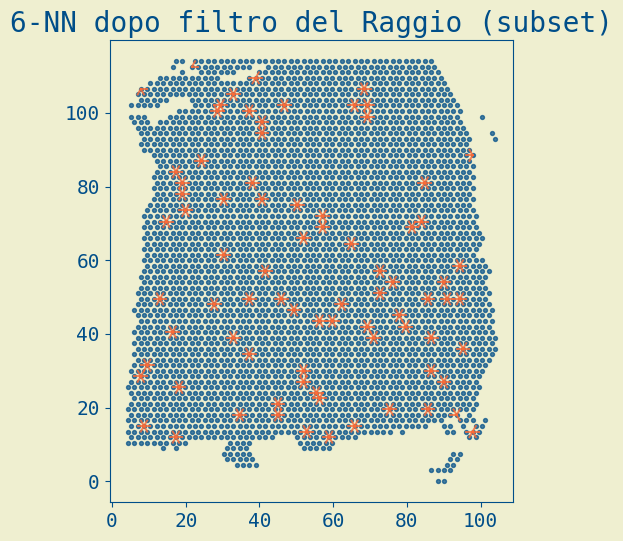

In [9]:
coords = index_to_cart  # shape: (n_spot, 2)
k = 1 + 6               # +1 perché include anche se stesso
nbrs = NearestNeighbors(n_neighbors=k, metric='euclidean').fit(coords)
dists, inds = nbrs.kneighbors(coords)

i = 0
vicini6 = inds[i, 1:]
distanze = dists[i, 1:]

# --- filtro per raggio ---
R = 1.74 

# liste di vicini/distanze filtrate per ogni nodo
vicini_filtrati  = []
distanze_filtrate = []

for i in range(len(coords)):
    di = dists[i, 1:]   # salta se stesso
    ii = inds[i, 1:]
    mask = di <= R      # "maggiore di R" viene rimosso
    vicini_filtrati.append(ii[mask])
    distanze_filtrate.append(di[mask])

np.random.seed(3)
sample = np.random.choice(len(coords), size=min(80, len(coords)), replace=False)

plt.figure(figsize=(6,6))
plt.scatter(coords[:,0], coords[:,1], s=8, alpha=0.7, facecolors=W, edgecolors=B, c=B)
for u in sample:
    for v in vicini_filtrati[u]:
        plt.plot([coords[u,0], coords[v,0]],
                 [coords[u,1], coords[v,1]],
                 lw=1.4, alpha=0.8,  color=Or)
plt.gca().set_aspect('equal'); plt.title('6-NN dopo filtro del Raggio (subset)')
plt.savefig("presentazioneCerinelli/SpotViciniFiltratiPerRaggio", dpi=1000)
plt.show()

In [10]:
binaryMasks = np.load("trasnformed_gdata.npy")  #tutte le binary mask dei 900 geni. 
number_of_genes = len(binaryMasks) 
number_of_spots = len(binaryMasks[0])
spat_var_genes = np.load("spatially_variable_genes.npy")
smallest   = select_top_spatially_variable_genes(scdata, 3000, 500, 3000)
gene_ids   = np.intersect1d(smallest, spat_var_genes)
gene_names = scdata.var.index.to_numpy()
array_data = scdata.X.toarray().T
subgenes = np.load("subgenes.npy", allow_pickle=True)
print("ciaoo")


ciaoo


In [11]:
binaryMasks = np.load("trasnformed_gdata.npy")  #tutte le binary mask dei 900 geni. 
                                                #mi dicono se nello spot 0 il gene è attivo o meno, 
                                                #se nello spot 1 il gene è attivo o meno ecc...

In [12]:
def labels_from_two_masks(maskA, maskB):
    A = (np.asarray(maskA) == 1)
    B = (np.asarray(maskB) == 1)
    labels = np.zeros_like(A, dtype=int)   # 0 = nessuno
    labels[np.where(A & ~B)] = 1           # 1 = solo A
    labels[np.where(~A & B)] = 2           # 2 = solo B
    labels[np.where(A & B)]  = 3           # 3 = A ∩ B
    return labels

def mask_to_set(mask):
    maskArray = np.asarray(mask)
    return set(np.flatnonzero(maskArray == 1)) #Mi torno gli indici (gli spot) in cui il gene è attivo

def are_touching(A_set, B_set, neighbors):
    count = 0
    if not A_set or not B_set:
        return False
    # itera l’insieme più piccolo, li scambio se B > A
    if len(A_set) > len(B_set):
        A_set, B_set = B_set, A_set
    for i in A_set:
        # se qualunque vicino i di A_set sta in B_set -> toccano
        if any((j in B_set) for j in neighbors[i]):
            count+=1
        
    if(count>50): #se più di 50 spot di A toccano gli spot di B, li considero adiacenti
        return True
    return False

def classify_relation_soft(maskA, maskB, neighbors,contain_tol=0.02):   # contain tol = tolleranaza. qua 2%
    A = mask_to_set(maskA) #Binary mask 1
    B = mask_to_set(maskB) #Binary mask 2


    inter = A & B #intersezione. es: A = {1,3,4}, B = {2,3,5} -> inter = {3}
    overlapA = (len(inter) / len(A)) if A else 0.0 #Quanti spot di A sono in B in %
    overlapB = (len(inter) / len(B)) if B else 0.0 #Quanti spot di B sono in A in %

    missA = len(A - B)  # quanti spot di A restano fuori da B (dilatato)
    missB = len(B - A)  # viceversa

    if len(A) > 0 and (missA / len(A) <= contain_tol):
        return ("A contenuto in B (tollerato)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB,
                 "missA": missA, "tol": contain_tol})

    if len(B) > 0 and (missB / len(B) <= contain_tol):
        return ("B contenuto in A (tollerato)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB,
                 "missB": missB, "tol": contain_tol})

    # --- casi rimanenti ---
    if inter and (overlapA > 0.3) and (overlapB > 0.3):
        return ("Parzialmente sovrapposti (overlap senza contenimento)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

    if are_touching(A, B, neighbors) and (overlapA < 0.03) and (overlapB < 0.03):
        return ("Si toccano (adiacenti, poco overlap)",
                {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

    return ("Disgiunti (poco overlap e adiacenza)",
            {"|A|": len(A), "|B|": len(B), "|A∩B|": len(inter),
                 "overlapA": overlapA, "overlapB": overlapB})

In [13]:
def index_subgenes(subgenes):
    """
    Crea due indici:
      - by_gene[gene_id] -> lista di entry (ordinata per sub_id)
      - by_pair[(gene_id, sub_id)] -> entry
    """
    by_gene = defaultdict(list)
    by_pair = {}
    for r in subgenes:
        by_gene[r["gene_id"]].append(r)
        by_pair[(r["gene_id"], r["sub_id"])] = r
    # ordina per sub_id per coerenza
    for gid in by_gene:
        by_gene[gid] = sorted(by_gene[gid], key=lambda r: r["sub_id"])
    return dict(by_gene), by_pair


In [14]:
by_gene, by_pair = index_subgenes(subgenes)

# tutte le entry del gene 8
g8_entries = by_gene.get(8, [])

# una entry specifica (gene 8, sub 1)
e_8_1 = by_pair.get((8, 1))   # dict con keys: gene_id, sub_id, count, comp_mask

In [15]:
def classify_subgene_pair(subgenes_by_pair, geneA, subA, geneB, subB, neighbors, contain_tol=0.01):
    """
    Confronta (geneA, subA) vs (geneB, subB) usando le comp_mask dei sotto-geni.
    Ritorna (label, info) come la tua classify_relation_soft.
    """
    eA = subgenes_by_pair.get((geneA, subA))
    eB = subgenes_by_pair.get((geneB, subB))
    if eA is None or eB is None:
        raise KeyError("Sottogene non trovato: controlla (gene_id, sub_id).")
    return classify_relation_soft(eA["comp_mask"], eB["comp_mask"], neighbors, contain_tol=contain_tol)


In [16]:
def labels_for_subgene_pair(subgenes_by_pair, geneA, subA, geneB, subB):
    eA = subgenes_by_pair[(geneA, subA)]
    eB = subgenes_by_pair[(geneB, subB)]
    return labels_from_two_masks(eA["comp_mask"], eB["comp_mask"])

In [17]:
mask0 = by_pair.get((0, 1))["comp_mask"]
mask1 = by_pair.get((14, 0))["comp_mask"]


A contenuto in B (tollerato) {'|A|': 86, '|B|': 2342, '|A∩B|': 85, 'overlapA': 0.9883720930232558, 'overlapB': 0.036293766011955594, 'missA': 1, 'tol': 0.02}


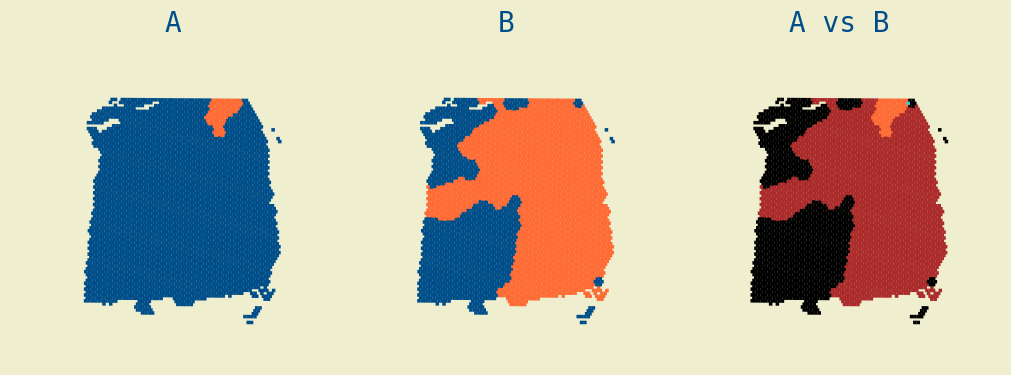

In [18]:
rel, info = classify_subgene_pair(by_pair, 0, 1, 14, 0, vicini_filtrati, contain_tol=0.02)
print(rel, info)

labels = labels_for_subgene_pair(by_pair, 0, 1, 14, 0)


fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2,1.2]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    mask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A",)

plot_spatial_scatter(
    scdata, 
    mask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")


plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

In [19]:
#1 sub gene viene comparato 3831 volte. Con tutti gli altri sub geni
sub_geneA = by_pair.get((0, 1))
counter = 0
for i in range(2,len(subgenes)):
    i_entries = by_gene.get(i, [])
    for j in range(len(i_entries)):
        rel, info = classify_subgene_pair(by_pair, 1, 0, i, j, vicini_filtrati, contain_tol=0.02)
        counter +=1
        print(i,j," -- ",counter, " -- ",rel, info)

2 0  --  1  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 2192, '|A∩B|': 0, 'overlapA': 0.0, 'overlapB': 0.0}
2 1  --  2  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 7, '|A∩B|': 0, 'overlapA': 0.0, 'overlapB': 0.0}
2 2  --  3  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 10, '|A∩B|': 0, 'overlapA': 0.0, 'overlapB': 0.0}
3 0  --  4  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 1568, '|A∩B|': 0, 'overlapA': 0.0, 'overlapB': 0.0}
3 1  --  5  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 27, '|A∩B|': 1, 'overlapA': 0.001394700139470014, 'overlapB': 0.037037037037037035}
3 2  --  6  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 36, '|A∩B|': 8, 'overlapA': 0.011157601115760111, 'overlapB': 0.2222222222222222}
3 3  --  7  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|': 39, '|A∩B|': 0, 'overlapA': 0.0, 'overlapB': 0.0}
3 4  --  8  --  Disgiunti (poco overlap e adiacenza) {'|A|': 717, '|B|

Si toccano (adiacenti, poco overlap) {'|A|': 717, '|B|': 2531, '|A∩B|': 17, 'overlapA': 0.023709902370990237, 'overlapB': 0.006716712761754247}


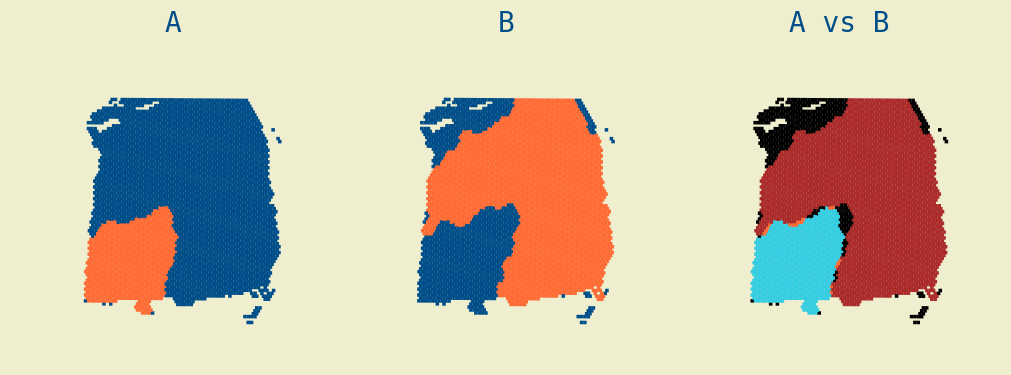

In [20]:
mask0 = by_pair.get((1, 0))["comp_mask"]
mask1 = by_pair.get((891, 0))["comp_mask"]

rel, info = classify_subgene_pair(by_pair, 1, 0, 891, 0, vicini_filtrati, contain_tol=0.02)
print(rel, info)

labels = labels_for_subgene_pair(by_pair, 1, 0, 891, 0,)


fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2,1.2]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    mask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A",)

plot_spatial_scatter(
    scdata, 
    mask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")


plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

Disgiunti (poco overlap e adiacenza) {'|A|': 1416, '|B|': 999, '|A∩B|': 23, 'overlapA': 0.016242937853107344, 'overlapB': 0.023023023023023025}


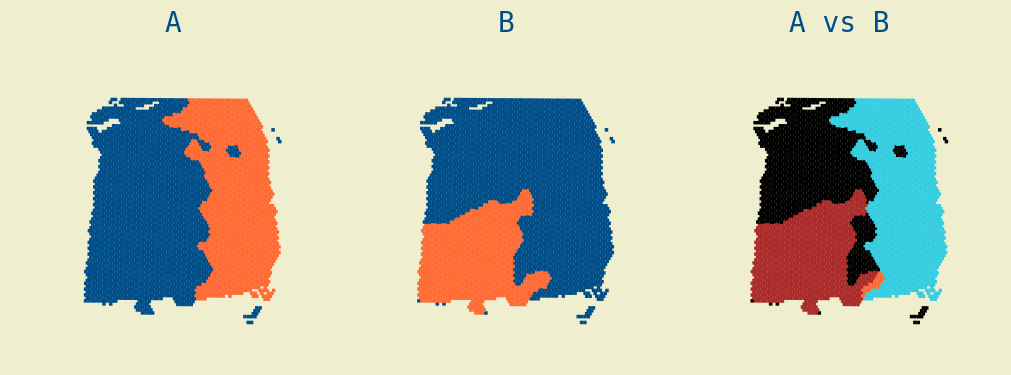

In [21]:
mask0 = by_pair.get((124, 0))["comp_mask"]
mask1 = by_pair.get((171, 0))["comp_mask"]

rel, info = classify_subgene_pair(by_pair, 124, 0, 171, 0, vicini_filtrati, contain_tol=0.02)
print(rel, info)

labels = labels_for_subgene_pair(by_pair, 124, 0, 171, 0,)


fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2,1.2]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    mask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A",)

plot_spatial_scatter(
    scdata, 
    mask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")


plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

In [22]:

def classify_relation_soft_matrix(maskA, maskB, neighbors,contain_tol=0.02):   # contain tol = tolleranaza. qua 1%
    A = mask_to_set(maskA) #Binary mask 1
    B = mask_to_set(maskB) #Binary mask 2


    inter = A & B #intersezione. es: A = {1,3,4}, B = {2,3,5} -> inter = {3}
    overlapA = (len(inter) / len(A)) if A else 0.0 #Quanti spot di A sono in B in %
    overlapB = (len(inter) / len(B)) if B else 0.0 #Quanti spot di B sono in A in %

    missA = len(A - B)  # quanti spot di A restano fuori da B (dilatato)
    missB = len(B - A)  # viceversa

    if len(A) > 0 and (missA / len(A) <= contain_tol):
        return ("A_CONTENUTO")

    if len(B) > 0 and (missB / len(B) <= contain_tol):
        return ("B_CONTENUTO")

    # --- casi rimanenti ---
    if inter and (overlapA > 0.3) and (overlapB > 0.3):
        return ("IN_COSTA") #Parzialmente sovrapposti (overlap senza contenimento)

    if are_touching(A, B, neighbors) and (overlapA < 0.03) and (overlapB < 0.03):
        return ("VICINI")

    return ("DISGIUNTI")

In [23]:
def pairwise_subgene_relations(subgenes, neighbors, contain_tol=0.02):

    results = []
    m = len(subgenes)
    for i in range(m):
        if i%25==0: 
            print(f"{i}/{m}")
        A = subgenes[i]
        for j in range(i + 1, m):            # <-- evita doppi (no j<i) e self-pair
            B = subgenes[j]
            if A["gene_id"] == B["gene_id"]:  # <-- salta stessa famiglia
                continue
            rel = classify_relation_soft_matrix(
                A["comp_mask"], B["comp_mask"], neighbors, contain_tol=contain_tol
            )
            if rel == "DISGIUNTI": #evito di mettere i disgiunti
                continue
            results.append({
                "gene_id_a": A["gene_id"],
                "sub_id_a":  A["sub_id"],
                "gene_id_b": B["gene_id"],
                "sub_id_b":  B["sub_id"],
                "rapporto":  rel               # es. "Si toccano", "A contenuto in B", ...
            })
            # results.append({ #lo faccio anche al contrario. se A 1,2 si tocca con B 5,7 allora di conseguenza B 5,7 si tocca con A 1,2. Siccome non vado sotto i lo salvo qua
            #     "gene_id_a": B["gene_id"],
            #     "sub_id_a":  B["sub_id"],
            #     "gene_id_b": A["gene_id"],
            #     "sub_id_b":  A["sub_id"],
            #     "rapporto":  rel               # es. "Si toccano", "A contenuto in B", ...
            # })
    return results

In [24]:
#DA SCOMMENTARE SE SI VUOLE RICREARE IL FILE GIGANTE DELLE RELAZIONI

# relations_without_disgiunti = pairwise_subgene_relations(subgenes, vicini_filtrati, contain_tol=0.02)

# # esempio: prima riga
# print(relations_without_disgiunti[0])
# print(relations_without_disgiunti[1])

In [25]:
# np.save("relations_without_disgiunti",relations_without_disgiunti)

In [26]:
relations_without_disgiunti = np.load("relations_without_disgiunti.npy", allow_pickle=True)

print(len(relations_without_disgiunti))

filtered = [r for r in relations_without_disgiunti if r["rapporto"] != "IN_COSTA"]

print(len(filtered))

filtered_vicini = [r for r in relations_without_disgiunti if r["rapporto"] == "VICINI"]

print(len(filtered_vicini))



1201725
1009282
55


In [27]:
for i in range(len(filtered_vicini)):
    print(filtered_vicini[i])

{'gene_id_a': 1, 'sub_id_a': 0, 'gene_id_b': 891, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 10, 'sub_id_a': 0, 'gene_id_b': 289, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 27, 'sub_id_a': 0, 'gene_id_b': 185, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 27, 'sub_id_a': 0, 'gene_id_b': 807, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 33, 'sub_id_a': 0, 'gene_id_b': 422, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 49, 'sub_id_a': 0, 'gene_id_b': 61, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 49, 'sub_id_a': 0, 'gene_id_b': 146, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 54, 'sub_id_a': 0, 'gene_id_b': 433, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 60, 'sub_id_a': 0, 'gene_id_b': 348, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 61, 'sub_id_a': 0, 'gene_id_b': 80, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 74, 'sub_id_a': 0, 'gene_id_b': 389, 'sub_id_b': 0, 'rapporto': 'VICINI'}
{'gene_id_a': 116, 'sub_id_a': 0, '

In [28]:
def node_id(gene_id: int, sub_id: int) -> str:
    return f"G_{gene_id}_S_{sub_id}"

def dump_gephi_nodes_and_edges(relations, nodes_csv="nodes.csv", edges_csv="edges.csv",
                               dedup_undirected=True, log_every=200000):
    
    nodes = {}           # Id -> (Label, Gene, Sub)
    seen_undir = set()   # per deduplicare gli archi non direzionali

    # prepara edges.csv
    with open(edges_csv, "w", encoding="utf-8") as fe:
        we = fe.write
        we("Source,Target,Type,Relation\n")
        for c, r in enumerate(relations, 1):
            ga, sa = int(r["gene_id_a"]), int(r["sub_id_a"])
            gb, sb = int(r["gene_id_b"]), int(r["sub_id_b"])
            rel = str(r["rapporto"]).upper()

            # crea (o registra) i nodi
            ida = node_id(ga, sa)
            idb = node_id(gb, sb)
            if ida not in nodes:
                nodes[ida] = (ida, ga, sa)   # Label = Id (già nel formato richiesto)
            if idb not in nodes:
                nodes[idb] = (idb, gb, sb)

            if rel == "A_CONTENUTO":
                # direzione A -> B
                we(f"{ida},{idb},Directed,A_CONTENUTO\n")
            elif rel == "B_CONTENUTO":
                # direzione B -> A
                we(f"{idb},{ida},Directed,B_CONTENUTO\n")  # normalizzo il valore Relation per colore coerente
            else:
                # non direzionali
                if dedup_undirected:
                    key = (ida, idb) if ida <= idb else (idb, ida)
                    if key in seen_undir:
                        continue
                    seen_undir.add(key)
                    s, t = key
                else:
                    s, t = ida, idb
                we(f"{s},{t},Undirected,{rel}\n")

            if log_every and c % log_every == 0:
                print(f"edges written: {c}")

    # --- scrivi nodes.csv ---
    with open(nodes_csv, "w", encoding="utf-8") as fn:
        wn = fn.write
        wn("Id,Label,Gene,Sub\n")
        for nid, (label, g, s) in nodes.items():
            wn(f"{nid},{label},{g},{s}\n")

    return nodes_csv, edges_csv

In [29]:
nodes_csv, edges_csv = dump_gephi_nodes_and_edges(filtered_vicini,
                                                  nodes_csv="gephi_graphs/subgenes_nodes_close.csv",
                                                  edges_csv="gephi_graphs/subgenes_edges_close.csv")

In [30]:
nodes_csv, edges_csv = dump_gephi_nodes_and_edges(relations_without_disgiunti,
                                                  nodes_csv="gephi_graphs/subgenes_nodes_all.csv",
                                                  edges_csv="gephi_graphs/subgenes_edges_all.csv")

edges written: 200000
edges written: 400000
edges written: 600000
edges written: 800000
edges written: 1000000
edges written: 1200000


In [31]:
nodes_csv, edges_csv = dump_gephi_nodes_and_edges(filtered,
                                                  nodes_csv="gephi_graphs/subgenes_nodes_no_costa.csv",
                                                  edges_csv="gephi_graphs/subgenes_edges_no_costa.csv")

edges written: 200000
edges written: 400000
edges written: 600000
edges written: 800000
edges written: 1000000


In [32]:
print(relations_without_disgiunti[0])

{'gene_id_a': 0, 'sub_id_a': 0, 'gene_id_b': 1, 'sub_id_b': 1, 'rapporto': 'B_CONTENUTO'}


In [33]:
def getPlotOfTwoGenesAndIntersection(geneA,subA,geneB,subB, path=None):
    mask0 = by_pair.get((geneA, subA))["comp_mask"]
    mask1 = by_pair.get((geneB, subB))["comp_mask"]

    rel, info = classify_subgene_pair(by_pair, geneA, subA, geneB, subB, vicini_filtrati, contain_tol=0.02)
    print(rel, info)

    labels = labels_for_subgene_pair(by_pair, geneA, subA, geneB, subB,)




    fig, (ax0,ax1,ax2,ax3,ax4) = plt.subplots(1, 5, figsize=(14, 5),
                                            gridspec_kw={"width_ratios":[1.2,1.2,1.2,1.2,1.2]}, 
                                            constrained_layout=True)

    plot_spatial_scatter(
        scdata, 
        np.sqrt(array_data[original_gene_ids[geneA]]), 
        cmap         = myCMAP, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax0,
        title        = "Raw "+gene_names[original_gene_ids[geneA]])

    plot_spatial_scatter(
        scdata, 
        mask0, 
        cmap         = myCMAP, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax1,
        title        = gene_names[original_gene_ids[geneA]]+" Sub BM")


    plot_spatial_scatter(
        scdata, 
        np.sqrt(array_data[original_gene_ids[geneB]]), 
        cmap         = myCMAP, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax2,
        title        = "Raw "+gene_names[original_gene_ids[geneB]])
    plot_spatial_scatter(
        scdata, 
        mask1, 
        cmap         = myCMAP, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax3,
        title        = gene_names[original_gene_ids[geneB]]+" Sub Bm")
    plot_spatial_scatter(
        scdata, 
        labels,
        cmap         = cmap_3, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax4,
        title        = "Comparison")
    
    if(path):
        plt.savefig(path,dpi=1000)

In [34]:
def getPlotOfOneGene(geneA,subA, path=None):
    mask0 = by_pair.get((geneA, subA))["comp_mask"]

    fig, (ax0,ax1) = plt.subplots(1, 2, figsize=(10, 5),
                                            gridspec_kw={"width_ratios":[1.2,1.2]}, 
                                            constrained_layout=True)

    plot_spatial_scatter(
        scdata, 
        np.sqrt(array_data[original_gene_ids[geneA]]), 
        cmap         = myCMAP, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax0,
        title        = "Raw "+gene_names[original_gene_ids[geneA]])

    plot_spatial_scatter(
        scdata, 
        mask0, 
        cmap         = myCMAP, 
        spines_color = W, 
        size         = 1.5, 
        shape        = "square",
        ax           = ax1,
        title        = gene_names[original_gene_ids[geneA]]+" Sub BM")
    
    if(path):
        plt.savefig(path,dpi=1000)

In [35]:
def getPlotOfGenes(genes, path=None):

    fig, axes = plt.subplots(
        len(genes), 2,
        figsize=(10, 20),
        constrained_layout=True
    )
    axes = np.atleast_2d(axes)
    if axes.shape == (2,):
        axes = axes.reshape(1, 2)

    for i, (gene,sub) in enumerate(genes):
        ax_raw = axes[i, 0]
        mask0 = by_pair.get((gene, sub))["comp_mask"]
        gid = original_gene_ids[gene]
        plot_spatial_scatter(
            scdata,
            np.sqrt(array_data[gid]),
            cmap         = myCMAP,
            spines_color = W,
            size         = 1.5,
            shape        = "square",
            ax           = ax_raw,
            title        = "Raw " + gene_names[gid]
        )
        ax_mask = axes[i, 1]
        plot_spatial_scatter(
            scdata, 
            mask0, 
            cmap         = myCMAP, 
            spines_color = W, 
            size         = 1.5, 
            shape        = "square",
            ax           = ax_mask,
            title        = gene_names[original_gene_ids[gene]]+" Sub BM")

    if path:
        plt.savefig(path, dpi=600)

    return fig


Si toccano (adiacenti, poco overlap) {'|A|': 630, '|B|': 2808, '|A∩B|': 18, 'overlapA': 0.02857142857142857, 'overlapB': 0.00641025641025641}


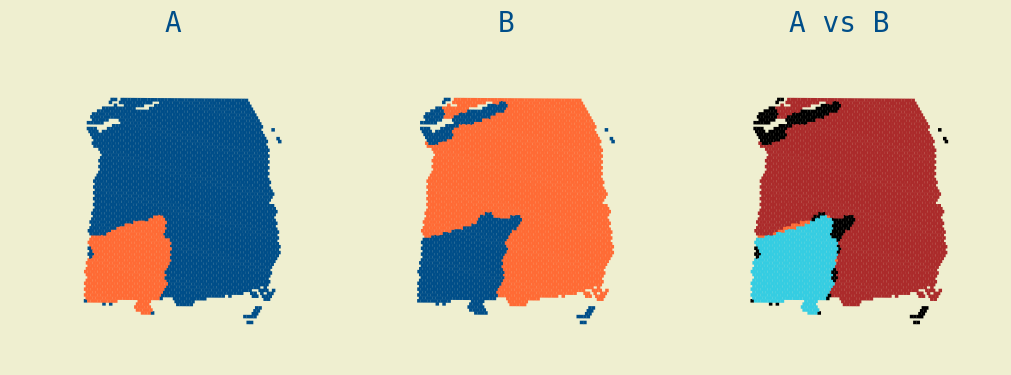

In [36]:
mask0 = by_pair.get((297, 0))["comp_mask"]
mask1 = by_pair.get((389, 0))["comp_mask"]

rel, info = classify_subgene_pair(by_pair, 297, 0, 389, 0, vicini_filtrati, contain_tol=0.02)
print(rel, info)

labels = labels_for_subgene_pair(by_pair, 297, 0, 389, 0,)


fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(10, 5),
                                           gridspec_kw={"width_ratios":[1.2, 1.2,1.2]}, 
                                           constrained_layout=True)
array_data = scdata.X.toarray().T

plot_spatial_scatter(
    scdata, 
    mask0, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax1,
    title        = "A",)

plot_spatial_scatter(
    scdata, 
    mask1, 
    cmap         = myCMAP, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax2,
    title        = "B")


plot_spatial_scatter(
    scdata,
    labels,                 # array 0..3
    cmap         = cmap_3,  # colormap discreta
    spines_color = W,
    size         = 1.5,
    shape        = "square",
    ax           = ax3,
    title        = "A vs B",
)

Si toccano (adiacenti, poco overlap) {'|A|': 974, '|B|': 1636, '|A∩B|': 28, 'overlapA': 0.028747433264887063, 'overlapB': 0.017114914425427872}


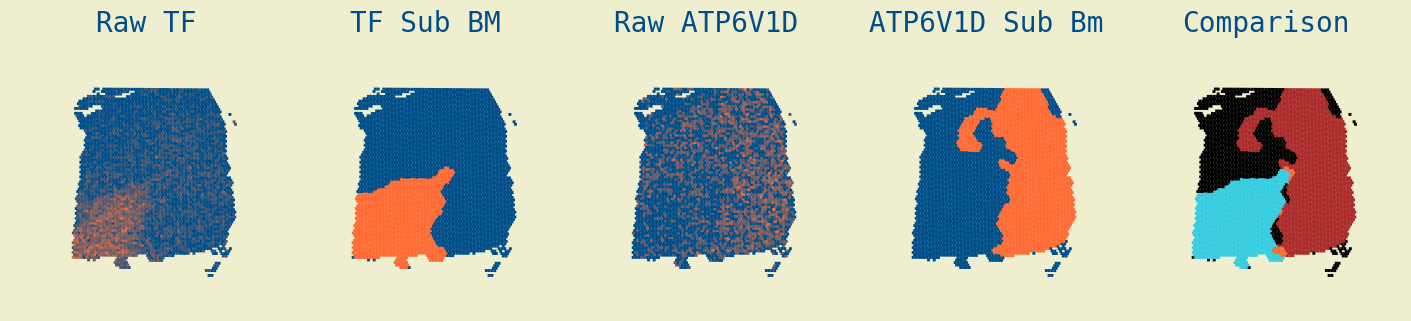

In [37]:
getPlotOfTwoGenesAndIntersection(194,0,703,0,path="presentazioneCerinelli/194_0_and_703_0.png")

Si toccano (adiacenti, poco overlap) {'|A|': 835, '|B|': 2246, '|A∩B|': 25, 'overlapA': 0.029940119760479042, 'overlapB': 0.011130899376669634}


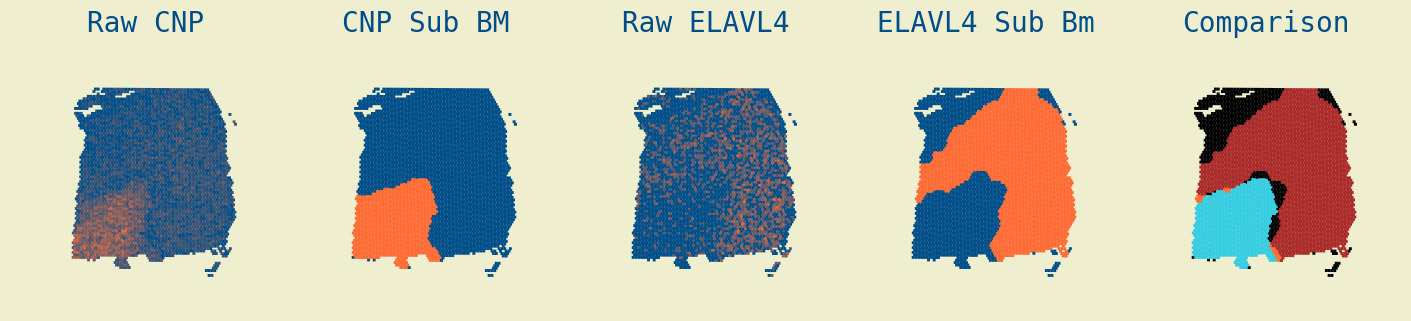

In [38]:
getPlotOfTwoGenesAndIntersection(807,0,27,0)

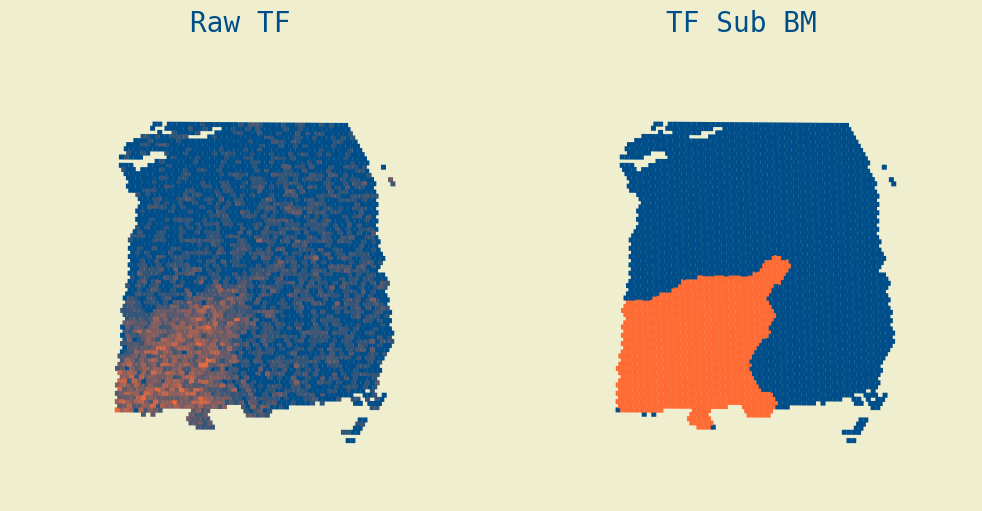

In [39]:
getPlotOfOneGene(194,0,path="presentazioneCerinelli/194_0_Alone.png")

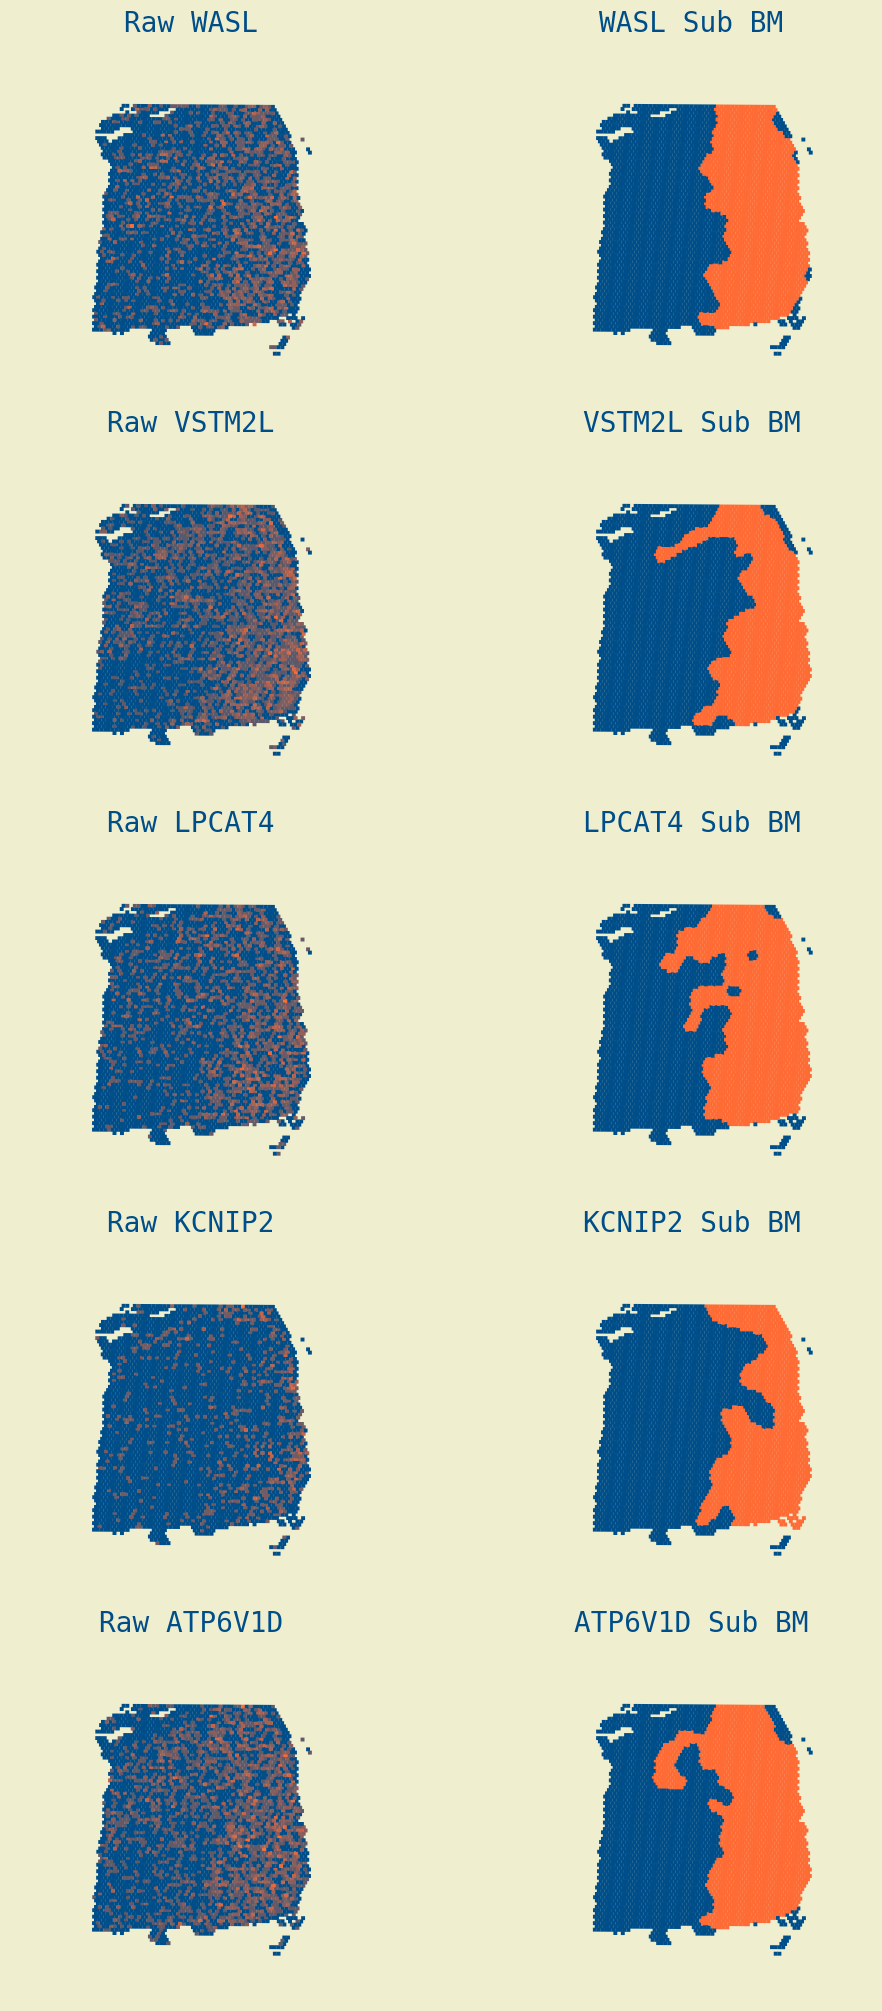

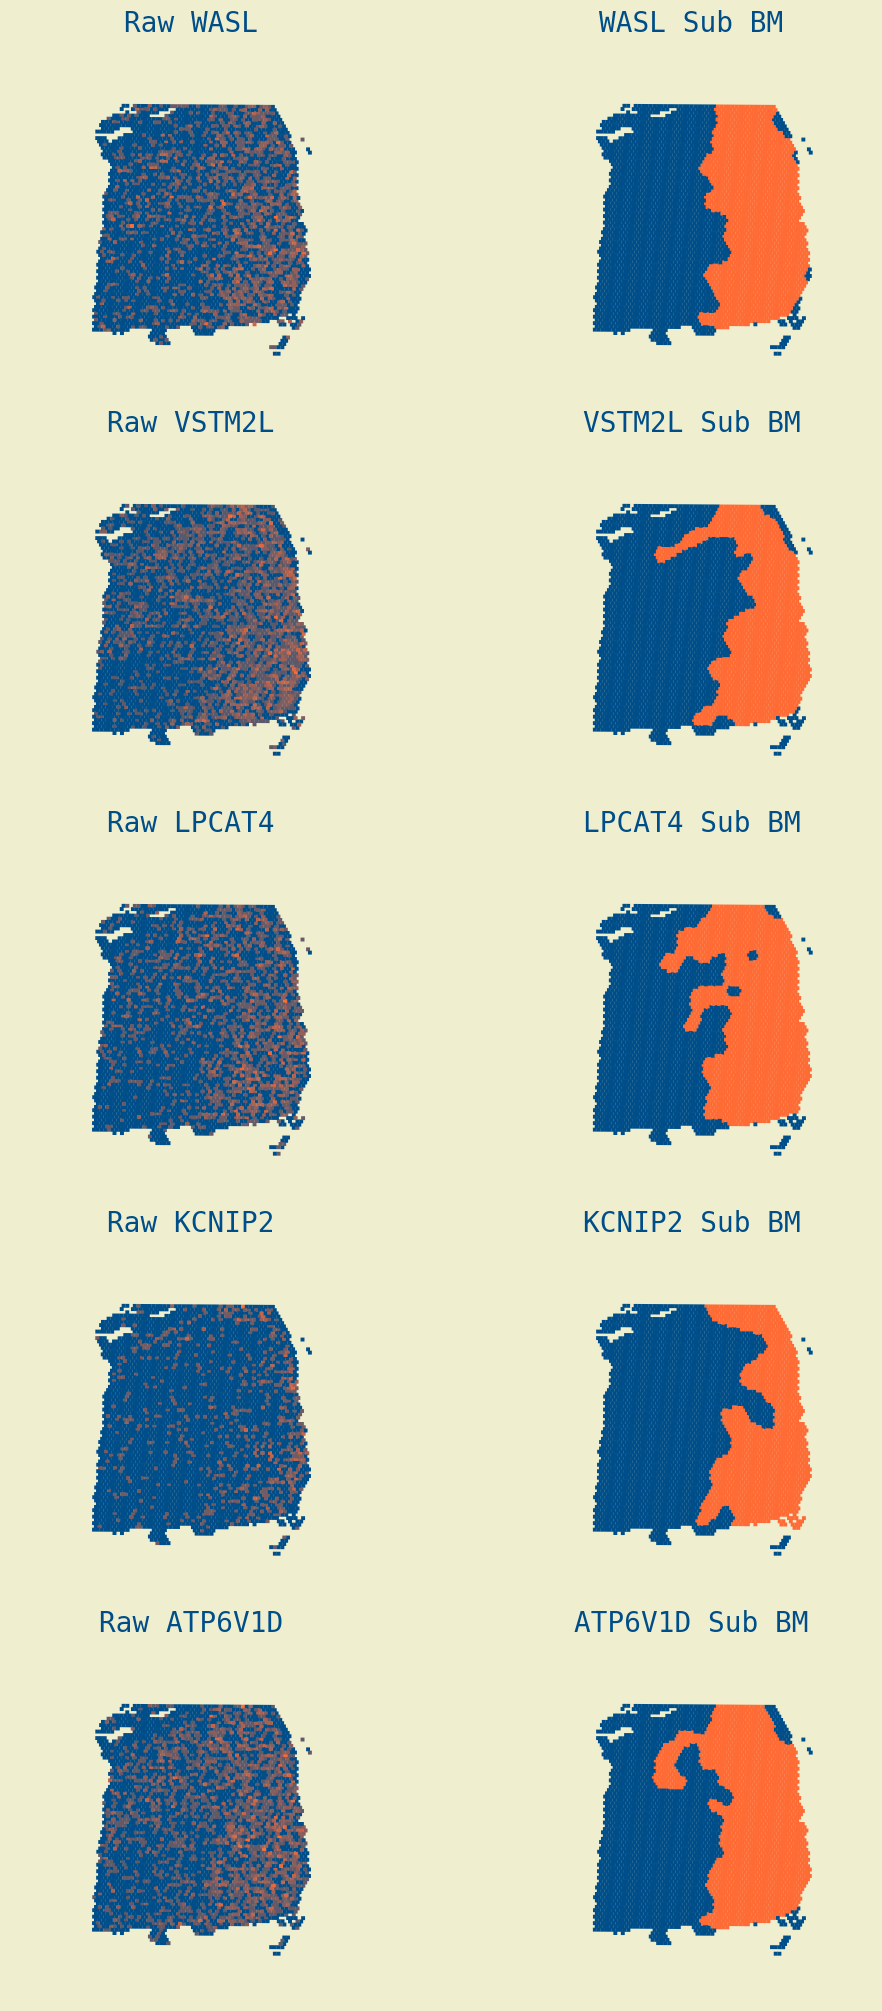

In [40]:
genes = [[399,0],[859,0],[731,0],[597,0],[703,0]]
getPlotOfGenes(genes,path="presentazioneCerinelli/closeGenesHub.png")

In [41]:

def labels_first_vs_rest(subgenes_by_pair, gene_sub_list):

    pairs = [tuple(x) for x in gene_sub_list]
    # quello da comparare
    g0, s0 = pairs[0]
    A = np.asarray(subgenes_by_pair[(g0, s0)]["comp_mask"]).astype(bool)

    # unione degli altri
    rest_masks = []
    for g, s in pairs[1:]:
        rest_masks.append(np.asarray(subgenes_by_pair[(g, s)]["comp_mask"]).astype(bool))
    B = np.logical_or.reduce(rest_masks)  # unione

    labels = np.zeros_like(A, dtype=np.uint8)
    labels[np.where(A & ~B)] = 1   # solo primo
    labels[np.where(~A & B)] = 2   # solo unione-resto
    labels[np.where(A & B)]  = 3   # intersezione

    return labels

# --- Colori (adatta c_first, c_rest, c_inter come preferisci) ---
c_first = "#0072B2"      # colore del PRIMO (solo A)
c_rest  = "#009E73"      # colore della UNIONE dei RESTANTI (solo B)
c_inter = "#D55E00"      # colore dell'INTERSEZIONE (A ∩ B)

cmap_3 = ListedColormap([
    (0,0,0,0),  # 0 -> trasparente
    c_first,    # 1 -> solo primo
    c_rest,     # 2 -> solo unione-resto
    c_inter,    # 3 -> intersezione
])


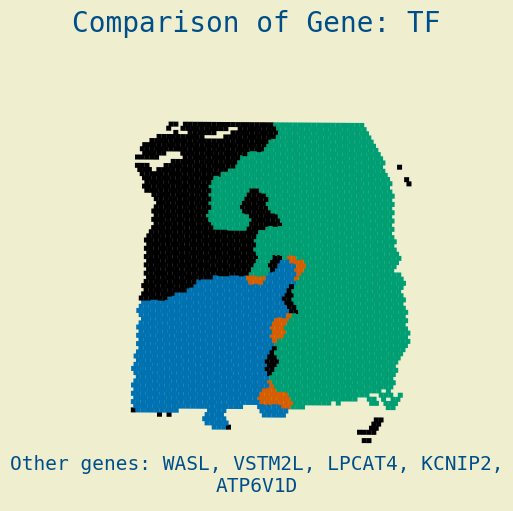

In [42]:
genes = [[194,0],[399,0],[859,0],[731,0],[597,0],[703,0]]

labels = labels_first_vs_rest(by_pair, genes)
fig, ax = plt.subplots(1, 1, figsize=(5, 5),
                                           gridspec_kw={"width_ratios":[1.2]}, 
                                           constrained_layout=True)
bottom_text = "Other genes: "+gene_names[original_gene_ids[399]]+", "+gene_names[original_gene_ids[859]]+", "+gene_names[original_gene_ids[731]]+", "+gene_names[original_gene_ids[597]]+", "+gene_names[original_gene_ids[703]]
fig = ax.figure
fig.text(
    0.5, 0.02, bottom_text,   # coordinata FIGURA, non axes
    ha="center", va="bottom", wrap=True
)

plot_spatial_scatter(
    scdata, 
    labels,
    cmap         = cmap_3, 
    spines_color = W, 
    size         = 1.5, 
    shape        = "square",
    ax           = ax,
    title        = "Comparison of Gene: "+gene_names[original_gene_ids[194]],
    )

In [43]:
import numpy as np
from collections import deque
from sklearn.metrics import silhouette_samples, silhouette_score

def _bfs_hop_dist(start, neighbors, targets_set, max_hops=None):
    """Distanze in hop da 'start' verso gli altri nodi; ritorna dict {node:dist}."""
    dist = {start: 0}
    q = deque([start])
    seen_targets = 1 if start in targets_set else 0
    while q:
        u = q.popleft()
        du = dist[u]
        if max_hops is not None and du >= max_hops:
            continue
        for v in neighbors[u]:
            if v not in dist:
                dist[v] = du + 1
                if v in targets_set:
                    seen_targets += 1
                q.append(v)
    return dist

def silhouette_between_two_subgenes(maskA, maskB, neighbors, max_hops=None):

    A = np.flatnonzero(np.asarray(maskA, dtype=bool))
    B = np.flatnonzero(np.asarray(maskB, dtype=bool))

    # costruiamo l’insieme dei campioni e le etichette
    nodes = np.concatenate([A, B])
    labels = np.concatenate([np.zeros(len(A), dtype=int), np.ones(len(B), dtype=int)])

    # matrice distanze (precomputed): hop distance sul grafo
    n = len(nodes)
    idx_of = {node: i for i, node in enumerate(nodes)}
    targets_set = set(nodes)

    D = np.zeros((n, n), dtype=float)
    # riempi con inf, metti 0 sulla diagonale
    D[:] = np.inf
    np.fill_diagonal(D, 0.0)

    for i, s in enumerate(nodes):
        dmap = _bfs_hop_dist(int(s), neighbors, targets_set, max_hops=max_hops)
        # scrivi solo le distanze verso nodi in 'nodes'
        for t, d in dmap.items():
            j = idx_of.get(t)
            if j is not None:
                D[i, j] = float(d)

    # se ci sono componenti disconnesse, sostituisci inf con una distanza grande
    if np.isinf(D).any():
        max_finite = np.max(D[np.isfinite(D)])
        fill_val = (max_finite + 1.0) if np.isfinite(max_finite) else 1e6
        D[~np.isfinite(D)] = fill_val

    # silhouette con metrica 'precomputed'
    sil_samp = silhouette_samples(D, labels, metric='precomputed')
    sil_avg  = silhouette_score(D, labels, metric='precomputed')

    # mapping per comodità
    sil_by_spot = {int(spot): float(s) for spot, s in zip(nodes, sil_samp)}
    lab_by_spot = {int(spot): int(l)    for spot, l in zip(nodes, labels)}

    return {
        "silhouette_score": float(sil_avg),
        "silhouette_samples": sil_by_spot,
        "labels": lab_by_spot,   # 0 = A, 1 = B
        "nodes": nodes.tolist()
    }


In [44]:
eA = by_pair[(433, 0)]
eB = by_pair[(54, 0)]

res = silhouette_between_two_subgenes(eA["comp_mask"], eB["comp_mask"], vicini_filtrati, max_hops=None)
print("Silhouette media:", res["silhouette_score"])

Silhouette media: 0.3038676490913278


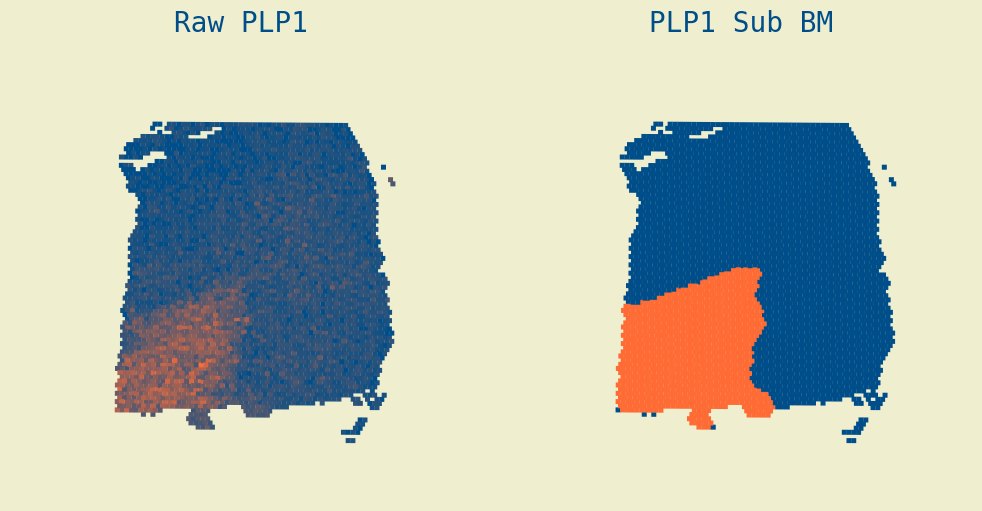

In [45]:
getPlotOfOneGene(437,0,path="presentazioneCerinelli/437_0_Alone.png")

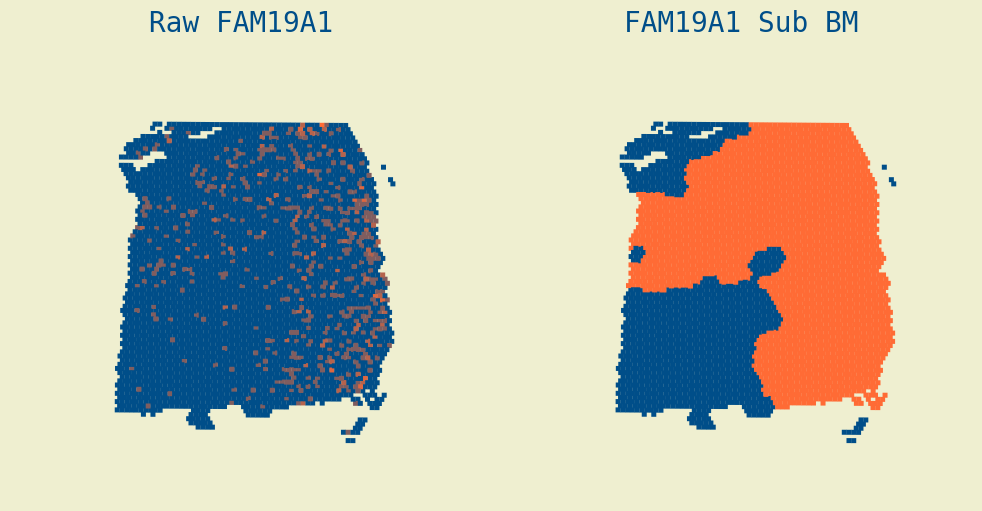

In [46]:
getPlotOfOneGene(183,0,path="presentazioneCerinelli/183_0_Alone.png")

In [3]:
getPlotOfTwoGenesAndIntersection(437,0,194,0)

NameError: name 'getPlotOfTwoGenesAndIntersection' is not defined